# Day 3 — Regression vs Classification, Overfitting & Model Tuning
### Hands-on Machine Learning Lab (Scikit-learn)

**Goal of today:** by the end of this notebook you will be able to take raw data, train a model,
*honestly* measure how good it is, detect when it is fooling itself (overfitting), validate it
properly with cross-validation, tune it with GridSearch, and finally hand in a **tuned, validated
predictive model** as your deliverable.

We go **from scratch → to advanced**, one small step at a time. Run every cell with `Shift + Enter`
and read the comments — they explain *why*, not just *how*.

---
**Roadmap**
0. Setup
1. Regression vs Classification — *seeing* the difference in data
2. Your first models, from scratch
3. Evaluating models — the metrics that matter
4. Overfitting & Underfitting — the most important idea in ML
5. Cross-validation — trusting your numbers
6. Hyperparameter tuning with GridSearchCV
7. Ensembles — Random Forest
8. 🎯 Deliverable: a tuned, validated pipeline you can save and reload

> **Datasets used (both ship inside scikit-learn, no internet needed):**
> - `load_diabetes` → a **regression** problem (predict a continuous disease-progression score)
> - `load_breast_cancer` → a **classification** problem (predict malignant vs benign)

## 0. Setup

First we import everything and fix a **random seed**. A fixed seed means everyone in the lab gets
the *same* numbers, so when you compare results with a classmate, differences come from your code —
not from luck.

In [1]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")   # keep the lab output clean

# A single seed used everywhere for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Nicer default plots
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (7, 4.5)

import sklearn
print("scikit-learn :", sklearn.__version__)
print("pandas       :", pd.__version__)
print("numpy        :", np.__version__)
print("\nSetup complete ✅")

scikit-learn : 1.8.0
pandas       : 3.0.2
numpy        : 2.4.4

Setup complete ✅


## 1. Regression vs Classification — *seeing* the difference

Both are **supervised learning**: we have input features `X` and a known answer `y`, and we want the
model to learn the mapping `X → y`. The *only* thing that separates the two tasks is **what `y` looks
like**:

| | **Regression** | **Classification** |
|---|---|---|
| Target `y` is... | a **number** on a continuous scale | a **category / label** |
| Example question | "*How much* will this house sell for?" | "*Is* this email spam — yes or no?" |
| Example output | `247500.0` | `"spam"` or `0 / 1` |
| Typical metrics | MAE, RMSE, R² | Accuracy, Precision, Recall, F1, ROC-AUC |
| Example algorithms | LinearRegression, Ridge, SVR, RandomForestRegressor | LogisticRegression, SVC, RandomForestClassifier |

The rule of thumb: **look at your target column.** Continuous number → regression. Fixed set of
labels → classification. Let's prove it by loading one dataset of each kind.

In [2]:
from sklearn.datasets import load_diabetes, load_breast_cancer

# ---- Regression dataset: diabetes ----
diabetes = load_diabetes(as_frame=True)
X_reg = diabetes.data          # features (already scaled in this dataset)
y_reg = diabetes.target        # CONTINUOUS target: disease progression after 1 year

# ---- Classification dataset: breast cancer ----
cancer = load_breast_cancer(as_frame=True)
X_clf = cancer.data            # 30 features measured from cell images
y_clf = cancer.target          # CATEGORICAL target: 0 = malignant, 1 = benign

print("REGRESSION  -> X_reg:", X_reg.shape, "| y_reg dtype:", y_reg.dtype)
print("CLASSIFY    -> X_clf:", X_clf.shape, "| y_clf dtype:", y_clf.dtype)

REGRESSION  -> X_reg: (442, 10) | y_reg dtype: float64
CLASSIFY    -> X_clf: (569, 30) | y_clf dtype: int64


In [3]:
# Peek at the regression target: many different real numbers -> CONTINUOUS
print("Regression target (first 8 values):")
print(y_reg.head(8).tolist())
print("min =", y_reg.min(), " max =", y_reg.max(), " unique values =", y_reg.nunique())

print("\nClassification target value counts (only two labels exist):")
print(y_clf.value_counts())
print("Label meaning:", dict(enumerate(cancer.target_names)))  # 0->malignant, 1->benign

Regression target (first 8 values):
[151.0, 75.0, 141.0, 206.0, 135.0, 97.0, 138.0, 63.0]
min = 25.0  max = 346.0  unique values = 214

Classification target value counts (only two labels exist):
target
1    357
0    212
Name: count, dtype: int64
Label meaning: {0: np.str_('malignant'), 1: np.str_('benign')}


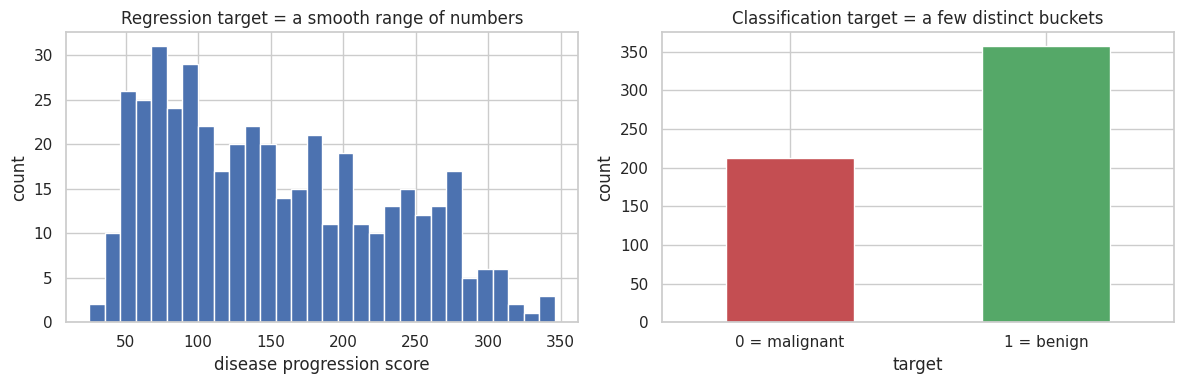

In [4]:
# Visual proof: the SHAPE of the target tells you the task type
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(y_reg, bins=30, color="#4C72B0", edgecolor="white")
axes[0].set_title("Regression target = a smooth range of numbers")
axes[0].set_xlabel("disease progression score"); axes[0].set_ylabel("count")

y_clf.value_counts().sort_index().plot(kind="bar", ax=axes[1],
                                       color=["#C44E52", "#55A868"])
axes[1].set_title("Classification target = a few distinct buckets")
axes[1].set_xticklabels(["0 = malignant", "1 = benign"], rotation=0)
axes[1].set_ylabel("count")

plt.tight_layout(); plt.show()

## 2. Your first models, from scratch

### 2.1 The golden rule: split your data *first*

We must **never** judge a model on the same data it learned from — that's like giving students the
exact exam questions to study. We split into:
- **Train set** → the model learns from this.
- **Test set** → locked in a vault, used **once** at the very end to estimate real-world performance.

`train_test_split` does this for us. For classification we add `stratify=y` so the train and test
sets keep the *same class proportions*.

In [5]:
from sklearn.model_selection import train_test_split

# Regression split (80% train / 20% test)
Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=RANDOM_STATE)

# Classification split — stratify keeps the malignant/benign ratio identical in both sets
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=RANDOM_STATE, stratify=y_clf)

print("Regression :", Xr_train.shape[0], "train rows |", Xr_test.shape[0], "test rows")
print("Classify   :", Xc_train.shape[0], "train rows |", Xc_test.shape[0], "test rows")
print("\nClass balance preserved by stratify:")
print("  train:", yc_train.value_counts(normalize=True).round(3).to_dict())
print("  test :", yc_test.value_counts(normalize=True).round(3).to_dict())

Regression : 353 train rows | 89 test rows
Classify   : 455 train rows | 114 test rows

Class balance preserved by stratify:
  train: {1: 0.626, 0: 0.374}
  test : {1: 0.632, 0: 0.368}


### 2.2 Train a regression model (Linear Regression)

Every scikit-learn model follows the **same 3-step pattern** — learn it once and it works for
*every* algorithm:

```python
model = SomeModel()      # 1. create
model.fit(X_train, y_train)   # 2. learn from training data
preds = model.predict(X_test) # 3. predict on new data
```

In [6]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()        # 1. create
lin_reg.fit(Xr_train, yr_train)     # 2. fit
yr_pred = lin_reg.predict(Xr_test)  # 3. predict

# Compare a few predictions against the truth
compare = pd.DataFrame({
    "actual":    yr_test.values[:8].round(1),
    "predicted": yr_pred[:8].round(1)
})
compare["error"] = (compare["predicted"] - compare["actual"]).round(1)
print(compare.to_string(index=False))

 actual  predicted  error
  219.0      139.5  -79.5
   70.0      179.5  109.5
  202.0      134.0  -68.0
  230.0      291.4   61.4
  111.0      123.8   12.8
   84.0       92.2    8.2
  242.0      258.2   16.2
  272.0      181.3  -90.7


### 2.3 Train a classification model (Logistic Regression)

Two new ideas appear here:

1. **Scaling.** Many models work better when all features are on a similar scale. We use
   `StandardScaler`. To avoid *data leakage* (the scaler peeking at test data), we wrap the scaler
   and the model together in a **`Pipeline`** — it scales using only the training data, automatically.
2. **`predict_proba`.** Classifiers can output not just a label, but the *probability* of each class.
   That probability is what metrics like ROC-AUC use.

In [7]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Pipeline = scale THEN classify, treated as one model
log_reg = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)),
])

log_reg.fit(Xc_train, yc_train)               # fit scaler + model in one call
yc_pred  = log_reg.predict(Xc_test)           # hard labels: 0 or 1
yc_proba = log_reg.predict_proba(Xc_test)[:, 1]  # probability of class "1" (benign)

preview = pd.DataFrame({
    "actual_label":   yc_test.values[:8],
    "predicted_label": yc_pred[:8],
    "prob_benign":    yc_proba[:8].round(3),
})
print(preview.to_string(index=False))

 actual_label  predicted_label  prob_benign
            0                0        0.000
            1                1        1.000
            0                0        0.006
            1                1        0.534
            0                0        0.000
            1                1        0.992
            1                1        1.000
            0                0        0.000


## 3. Evaluating models — the metrics that matter

"It works" is not a measurement. We need numbers. Regression and classification use **different**
metrics because their targets are different.

### 3.1 Regression metrics

| Metric | What it means | Good value |
|---|---|---|
| **MAE** (Mean Absolute Error) | average size of the error, in the target's units | lower (0 = perfect) |
| **MSE** (Mean Squared Error) | like MAE but squares errors, so big mistakes hurt more | lower |
| **RMSE** (Root MSE) | square root of MSE → back in the target's units; the popular one | lower |
| **R²** (R-squared) | fraction of variance explained; 1.0 = perfect, 0 = no better than predicting the mean | higher |

> Intuition: **RMSE** tells you "typically how far off am I?" and **R²** tells you "how much of the
> pattern did I capture?"

In [8]:
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                             root_mean_squared_error, r2_score)

mae  = mean_absolute_error(yr_test, yr_pred)
mse  = mean_squared_error(yr_test, yr_pred)
rmse = root_mean_squared_error(yr_test, yr_pred)
r2   = r2_score(yr_test, yr_pred)

print("Regression performance (Linear Regression)")
print(f"  MAE  = {mae:8.2f}   (off by ~{mae:.0f} score-points on average)")
print(f"  MSE  = {mse:8.2f}")
print(f"  RMSE = {rmse:8.2f}")
print(f"  R^2  = {r2:8.3f}   (model explains ~{r2*100:.0f}% of the variation)")

Regression performance (Linear Regression)
  MAE  =    42.79   (off by ~43 score-points on average)
  MSE  =  2900.19
  RMSE =    53.85
  R^2  =    0.453   (model explains ~45% of the variation)


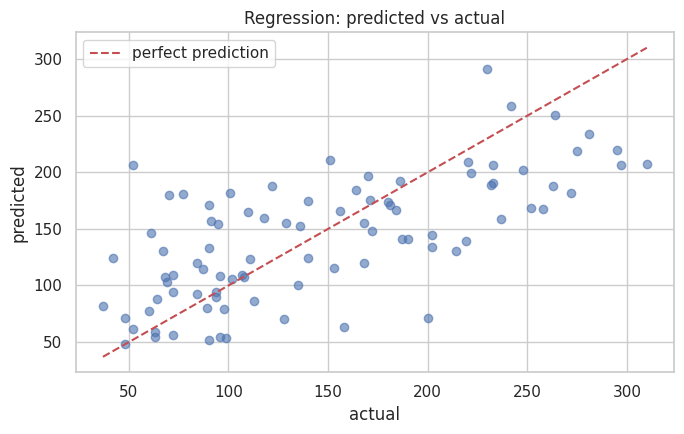

In [9]:
# A predicted-vs-actual plot: perfect predictions land on the red diagonal
plt.figure()
plt.scatter(yr_test, yr_pred, alpha=0.6, color="#4C72B0")
lims = [min(yr_test.min(), yr_pred.min()), max(yr_test.max(), yr_pred.max())]
plt.plot(lims, lims, "r--", label="perfect prediction")
plt.xlabel("actual"); plt.ylabel("predicted")
plt.title("Regression: predicted vs actual")
plt.legend(); plt.tight_layout(); plt.show()

### 3.2 Classification metrics

Accuracy alone can lie. Imagine a disease that affects 1% of people: a model that always says
"healthy" is **99% accurate** and **completely useless**. So we look deeper, using the
**confusion matrix**:

- **TP / TN** — correct predictions (true positive / true negative)
- **FP** — false alarm (predicted positive, actually negative)
- **FN** — missed case (predicted negative, actually positive)

| Metric | Formula (intuition) | Answers the question |
|---|---|---|
| **Accuracy** | correct / total | overall, how often right? |
| **Precision** | TP / (TP + FP) | when it says "positive", how often is it right? |
| **Recall** | TP / (TP + FN) | of all real positives, how many did it catch? |
| **F1** | harmonic mean of precision & recall | one number balancing the two |
| **ROC-AUC** | area under the ROC curve | how well does it *rank* positives above negatives? |

> Precision vs Recall is a **trade-off**. In cancer screening you care a lot about **recall** —
> missing a malignant case (FN) is far worse than a false alarm.

In [10]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report)

print("Classification performance (Logistic Regression)")
print(f"  Accuracy  = {accuracy_score(yc_test, yc_pred):.3f}")
print(f"  Precision = {precision_score(yc_test, yc_pred):.3f}")
print(f"  Recall    = {recall_score(yc_test, yc_pred):.3f}")
print(f"  F1-score  = {f1_score(yc_test, yc_pred):.3f}")

print("\nFull per-class report:")
print(classification_report(yc_test, yc_pred,
                            target_names=cancer.target_names))

Classification performance (Logistic Regression)
  Accuracy  = 0.982
  Precision = 0.986
  Recall    = 0.986
  F1-score  = 0.986

Full per-class report:
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



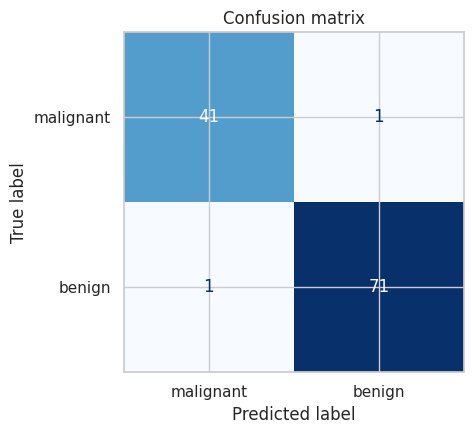

Read it as: rows = TRUE label, columns = PREDICTED label.
Diagonal = correct. Off-diagonal = mistakes.


In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(yc_test, yc_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=cancer.target_names)
disp.plot(cmap="Blues", colorbar=False)
plt.title("Confusion matrix"); plt.tight_layout(); plt.show()

print("Read it as: rows = TRUE label, columns = PREDICTED label.")
print("Diagonal = correct. Off-diagonal = mistakes.")

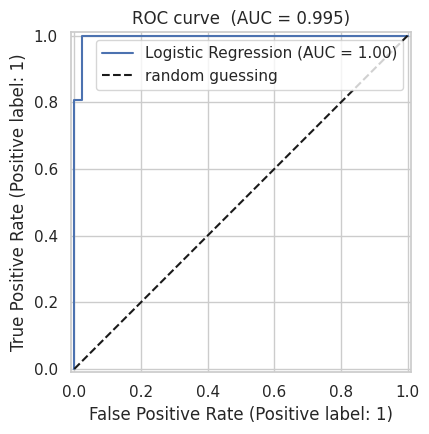

AUC = 0.995  (1.0 = perfect ranking, 0.5 = coin flip)


In [12]:
from sklearn.metrics import roc_auc_score, RocCurveDisplay

auc = roc_auc_score(yc_test, yc_proba)
RocCurveDisplay.from_predictions(yc_test, yc_proba, name="Logistic Regression")
plt.plot([0, 1], [0, 1], "k--", label="random guessing")
plt.title(f"ROC curve  (AUC = {auc:.3f})")
plt.legend(); plt.tight_layout(); plt.show()

print(f"AUC = {auc:.3f}  (1.0 = perfect ranking, 0.5 = coin flip)")

## 4. Overfitting & Underfitting — the most important idea in ML

When a model learns, it can fail in two opposite ways:

- **Underfitting (high bias):** too simple, misses the real pattern. Bad on *both* train and test.
- **Overfitting (high variance):** too complex, memorises the training data including its noise.
  *Great* on train, *bad* on test — it didn't learn, it memorised.

The sweet spot is the **bias–variance trade-off**: complex enough to capture the pattern, simple
enough to generalise.

**How do you detect overfitting?** Compare the **training score** with the **test/validation score**.
A large gap (train good, test bad) is the fingerprint of overfitting. Let's *create* overfitting on
purpose by growing a Decision Tree deeper and deeper.

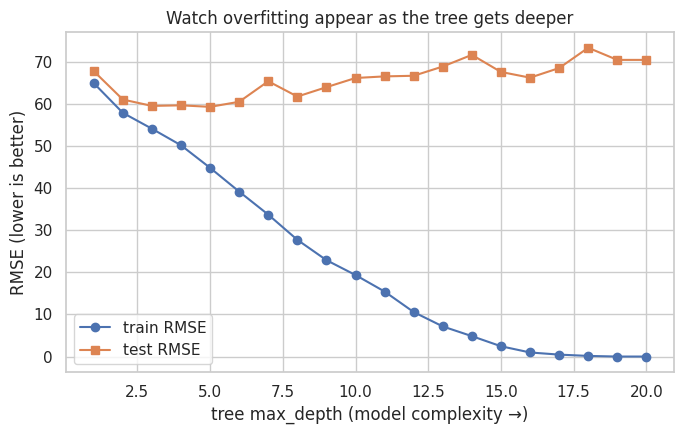

Train RMSE keeps DROPPING (memorising), but test RMSE bottoms out around depth 5
After that, the train/test GAP widens = OVERFITTING.


In [13]:
from sklearn.tree import DecisionTreeRegressor

depths = range(1, 21)
train_rmse, test_rmse = [], []

for d in depths:
    tree = DecisionTreeRegressor(max_depth=d, random_state=RANDOM_STATE)
    tree.fit(Xr_train, yr_train)
    train_rmse.append(root_mean_squared_error(yr_train, tree.predict(Xr_train)))
    test_rmse.append(root_mean_squared_error(yr_test,  tree.predict(Xr_test)))

plt.figure()
plt.plot(depths, train_rmse, "o-", label="train RMSE")
plt.plot(depths, test_rmse,  "s-", label="test RMSE")
plt.xlabel("tree max_depth (model complexity →)")
plt.ylabel("RMSE (lower is better)")
plt.title("Watch overfitting appear as the tree gets deeper")
plt.legend(); plt.tight_layout(); plt.show()

best_d = depths[int(np.argmin(test_rmse))]
print(f"Train RMSE keeps DROPPING (memorising), but test RMSE bottoms out around depth {best_d}")
print("After that, the train/test GAP widens = OVERFITTING.")

### 4.1 Validation curves the easy way

scikit-learn's `validation_curve` automates the loop above *and* uses cross-validation (Section 5)
for each setting. Here we sweep the depth of a classification tree.

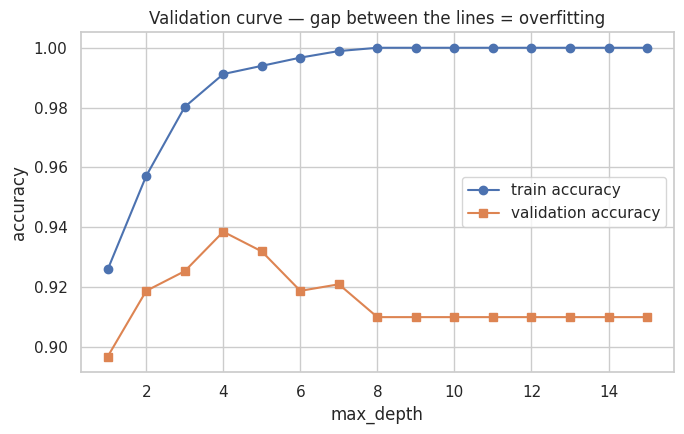

In [14]:
from sklearn.model_selection import validation_curve
from sklearn.tree import DecisionTreeClassifier

param_range = range(1, 16)
train_scores, val_scores = validation_curve(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    Xc_train, yc_train,
    param_name="max_depth", param_range=list(param_range),
    cv=5, scoring="accuracy", n_jobs=-1)

plt.figure()
plt.plot(param_range, train_scores.mean(axis=1), "o-", label="train accuracy")
plt.plot(param_range, val_scores.mean(axis=1),  "s-", label="validation accuracy")
plt.xlabel("max_depth"); plt.ylabel("accuracy")
plt.title("Validation curve — gap between the lines = overfitting")
plt.legend(); plt.tight_layout(); plt.show()

**Ways to fight overfitting (toolbox to remember):**
- Get **more training data**.
- Use a **simpler model** / fewer features.
- Add **regularisation** (e.g. `Ridge`/`Lasso`, the `C` in LogisticRegression/SVC).
- For trees: limit `max_depth`, increase `min_samples_leaf`.
- Use **ensembles** like Random Forest (Section 7).
- Always **cross-validate** (Section 5) so you notice the gap early.

## 5. Cross-validation — trusting your numbers

A single train/test split is fragile: get a "lucky" or "unlucky" split and your score swings.
**k-fold cross-validation** fixes this. With `k=5`:

1. Split the training data into 5 equal folds.
2. Train on 4 folds, validate on the 5th. Record the score.
3. Repeat so every fold is the validation set exactly once.
4. Average the 5 scores → a **stable** estimate, plus a standard deviation telling you how much it
   wobbles.

For classification we use **StratifiedKFold** (keeps class balance in each fold).

In [15]:
from sklearn.model_selection import cross_val_score

# 5-fold CV on the regression model. scoring is negative RMSE (sklearn maximises scores,
# so "better" = closer to 0). We flip the sign back to read it normally.
cv_scores = cross_val_score(LinearRegression(), Xr_train, yr_train,
                            cv=5, scoring="neg_root_mean_squared_error")
rmse_folds = -cv_scores
print("RMSE per fold :", np.round(rmse_folds, 2))
print(f"Mean RMSE     : {rmse_folds.mean():.2f}  (+/- {rmse_folds.std():.2f})")
print("\nThe +/- is your confidence: one split could have hidden this spread.")

RMSE per fold : [52.53 58.94 52.09 56.5  59.81]
Mean RMSE     : 55.97  (+/- 3.18)

The +/- is your confidence: one split could have hidden this spread.


In [16]:
from sklearn.model_selection import StratifiedKFold, cross_validate

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# cross_validate can report SEVERAL metrics at once
scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]
results = cross_validate(log_reg, Xc_train, yc_train, cv=skf, scoring=scoring)

summary = pd.DataFrame({
    m: [results[f"test_{m}"].mean(), results[f"test_{m}"].std()]
    for m in scoring
}, index=["mean", "std"]).T.round(3)
print("5-fold cross-validation of the Logistic Regression pipeline:\n")
print(summary.to_string())

5-fold cross-validation of the Logistic Regression pipeline:

            mean    std
accuracy   0.978  0.010
precision  0.979  0.016
recall     0.986  0.013
f1         0.983  0.008
roc_auc    0.996  0.005


## 6. Hyperparameter tuning with GridSearchCV

**Parameters** are learned by the model (e.g. the weights in linear regression).
**Hyperparameters** are knobs *we* set *before* training (e.g. a tree's `max_depth`).
Picking good ones by hand is slow. `GridSearchCV`:

1. takes a grid of hyperparameter values,
2. tries **every combination**,
3. scores each one with cross-validation,
4. refits the best combination on all the training data.

Because we use a Pipeline, we address a step's hyperparameter with the
`stepname__hyperparameter` syntax (double underscore).

In [17]:
from sklearn.model_selection import GridSearchCV

# Tune a Decision Tree classifier inside a scaling pipeline
tree_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", DecisionTreeClassifier(random_state=RANDOM_STATE)),
])

param_grid = {
    "clf__max_depth":        [2, 3, 4, 5, 6, 8, None],
    "clf__min_samples_leaf": [1, 3, 5, 10],
}

grid = GridSearchCV(tree_pipe, param_grid, cv=5,
                    scoring="f1", n_jobs=-1, return_train_score=True)
grid.fit(Xc_train, yc_train)

print("Combinations tried :", len(grid.cv_results_["params"]))
print("Best hyperparameters:", grid.best_params_)
print(f"Best CV F1 score    : {grid.best_score_:.3f}")

Combinations tried : 28
Best hyperparameters: {'clf__max_depth': 4, 'clf__min_samples_leaf': 1}
Best CV F1 score    : 0.951


In [18]:
# Inspect the top 5 combinations to see how the search reasoned
res = pd.DataFrame(grid.cv_results_)
top = (res.sort_values("rank_test_score")
          .loc[:, ["param_clf__max_depth", "param_clf__min_samples_leaf",
                   "mean_test_score", "std_test_score", "mean_train_score"]]
          .head(5)
          .rename(columns={"param_clf__max_depth": "max_depth",
                           "param_clf__min_samples_leaf": "min_samples_leaf",
                           "mean_test_score": "cv_f1",
                           "std_test_score": "cv_f1_std",
                           "mean_train_score": "train_f1"}))
print("Top 5 hyperparameter combinations:\n")
print(top.round(3).to_string(index=False))
print("\nNote how train_f1 near 1.0 with a lower cv_f1 signals overfitting for deep trees.")

Top 5 hyperparameter combinations:

max_depth  min_samples_leaf  cv_f1  cv_f1_std  train_f1
        4                 1  0.951      0.014     0.993
        5                 5  0.950      0.015     0.981
        5                 3  0.950      0.010     0.985
        6                 3  0.950      0.010     0.985
        8                 3  0.950      0.010     0.985

Note how train_f1 near 1.0 with a lower cv_f1 signals overfitting for deep trees.


## 7. Ensembles — Random Forest

A single decision tree overfits easily. An **ensemble** combines many models to do better than any
one alone. A **Random Forest** uses **bagging**:

- train **many** trees, each on a random sample of the rows **and** a random subset of the features,
- for prediction, **average** them (regression) or take a **majority vote** (classification).

Each tree overfits in its *own* way, and averaging cancels out their individual mistakes → lower
variance, better generalisation. Let's compare three classifiers head-to-head with cross-validation.

In [19]:
from sklearn.ensemble import RandomForestClassifier

models = {
    "Logistic Regression": log_reg,
    "Single Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest":        RandomForestClassifier(n_estimators=300,
                                                   random_state=RANDOM_STATE, n_jobs=-1),
}

rows = []
for name, model in models.items():
    s = cross_val_score(model, Xc_train, yc_train, cv=skf, scoring="f1")
    rows.append({"model": name, "cv_f1_mean": s.mean(), "cv_f1_std": s.std()})

leaderboard = pd.DataFrame(rows).sort_values("cv_f1_mean", ascending=False)
print("Model comparison (5-fold CV, F1 score):\n")
print(leaderboard.round(3).to_string(index=False))

Model comparison (5-fold CV, F1 score):

               model  cv_f1_mean  cv_f1_std
 Logistic Regression       0.983      0.008
       Random Forest       0.972      0.014
Single Decision Tree       0.932      0.014


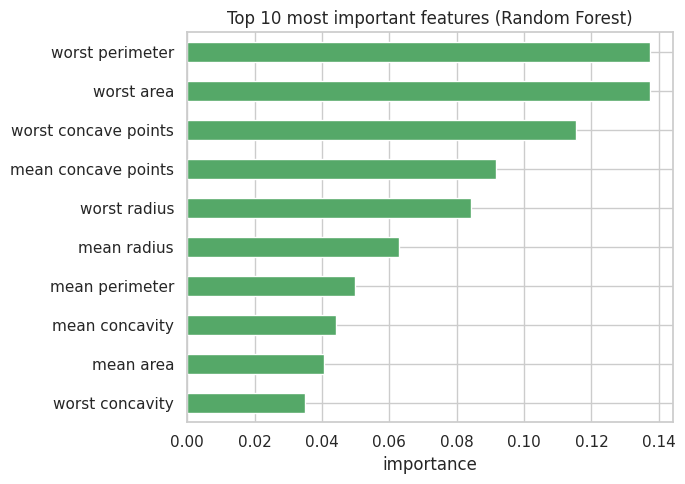

In [20]:
# Which measurements does the forest rely on most? -> feature importances
rf = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(Xc_train, yc_train)

importances = (pd.Series(rf.feature_importances_, index=X_clf.columns)
                 .sort_values(ascending=False).head(10))

plt.figure(figsize=(7, 5))
importances.sort_values().plot(kind="barh", color="#55A868")
plt.title("Top 10 most important features (Random Forest)")
plt.xlabel("importance"); plt.tight_layout(); plt.show()

## 8. 🎯 Deliverable — a tuned, validated predictive model

Now we put **everything** together into one professional workflow, exactly what you should hand in:

1. **Pipeline**: scaling + Random Forest (no leakage).
2. **GridSearchCV**: tune hyperparameters with cross-validation.
3. **Final test-set evaluation**: the vault opens *once*, on data the model has never seen.
4. **Save** the trained model to disk, then **reload** it to prove it works for deployment.

In [21]:
# 1 + 2 : Pipeline tuned with GridSearchCV
final_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)),
])

final_grid = {
    "clf__n_estimators":     [200, 400],
    "clf__max_depth":        [4, 6, None],
    "clf__min_samples_leaf": [1, 2, 4],
}

final_search = GridSearchCV(final_pipe, final_grid, cv=skf,
                            scoring="f1", n_jobs=-1)
final_search.fit(Xc_train, yc_train)

best_model = final_search.best_estimator_
print("Chosen hyperparameters:", final_search.best_params_)
print(f"Cross-validated F1 (training data): {final_search.best_score_:.3f}")

Chosen hyperparameters: {'clf__max_depth': None, 'clf__min_samples_leaf': 1, 'clf__n_estimators': 200}
Cross-validated F1 (training data): 0.970


================ FINAL HELD-OUT TEST RESULTS ================
  Accuracy  : 0.956
  Precision : 0.959
  Recall    : 0.972
  F1-score  : 0.966
  ROC-AUC   : 0.993


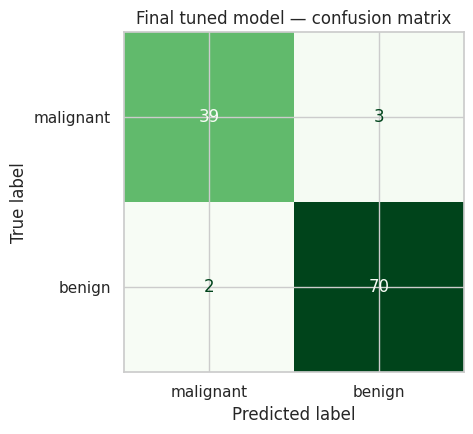

In [22]:
# 3 : Open the vault — evaluate ONCE on the untouched test set
final_pred  = best_model.predict(Xc_test)
final_proba = best_model.predict_proba(Xc_test)[:, 1]

print("================ FINAL HELD-OUT TEST RESULTS ================")
print(f"  Accuracy  : {accuracy_score(yc_test, final_pred):.3f}")
print(f"  Precision : {precision_score(yc_test, final_pred):.3f}")
print(f"  Recall    : {recall_score(yc_test, final_pred):.3f}")
print(f"  F1-score  : {f1_score(yc_test, final_pred):.3f}")
print(f"  ROC-AUC   : {roc_auc_score(yc_test, final_proba):.3f}")
print("============================================================")

ConfusionMatrixDisplay(confusion_matrix(yc_test, final_pred),
                       display_labels=cancer.target_names).plot(cmap="Greens", colorbar=False)
plt.title("Final tuned model — confusion matrix"); plt.tight_layout(); plt.show()

In [23]:
# 4 : Save the model, then reload it and predict — this is how models go to production
import joblib

joblib.dump(best_model, "final_model.joblib")
print("Model saved to final_model.joblib")

reloaded = joblib.load("final_model.joblib")
sample = Xc_test.iloc[[0]]
pred_label = reloaded.predict(sample)[0]
print("\nReloaded model predicts on one new sample:",
      cancer.target_names[pred_label],
      f"(actual: {cancer.target_names[yc_test.iloc[0]]})")
print("\n✅ Deliverable complete: a tuned, cross-validated, saved predictive model.")

Model saved to final_model.joblib



Reloaded model predicts on one new sample: malignant (actual: malignant)

✅ Deliverable complete: a tuned, cross-validated, saved predictive model.


## ✅ Recap & Student Exercises

**Today you learned to:**
- Tell **regression** from **classification** by looking at the target.
- Follow the universal **create → fit → predict** pattern, with **Pipelines** to avoid leakage.
- Pick the **right metrics** (RMSE/R² vs accuracy/precision/recall/F1/ROC-AUC).
- **Spot overfitting** via the train-vs-test gap and validation curves.
- **Cross-validate** for trustworthy scores.
- **Tune** with `GridSearchCV` and build a **Random Forest** ensemble.
- Ship a **saved, validated model**.

### 🧪 Try these yourself
1. **Swap the model.** Replace `RandomForestClassifier` with `GradientBoostingClassifier`. Does the
   final F1 improve?
2. **New metric.** Re-run the GridSearch with `scoring="recall"`. How do the chosen hyperparameters
   and the confusion matrix change? Why might a hospital prefer this?
3. **Regression deliverable.** Repeat Section 8 for the **diabetes** dataset using
   `RandomForestRegressor`, tuning `max_depth`, and reporting RMSE + R² on the test set.
4. **Break it on purpose.** Set the tree `max_depth=None` and `min_samples_leaf=1`. Show the
   train-vs-test gap and explain what's happening.
5. **Bring your own data.** Load a CSV with `pd.read_csv(...)`, decide if it's regression or
   classification, and run the whole workflow.

### 📖 Mini-glossary
- **Feature (X):** an input column. **Target (y):** the answer to predict.
- **Hyperparameter:** a knob set before training (e.g. `max_depth`).
- **Data leakage:** test information sneaking into training → falsely high scores.
- **Bias / Variance:** underfitting / overfitting tendencies.
- **Estimator:** any scikit-learn object with `.fit()`.